# COGS 108 - Final Project

# First Set Advantage in 2019 NCAA Division I Women's Volleyball

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [ X ] NO - keep private

## Link to video
https://drive.google.com/file/d/13gWgo-LMNPk3r0Lr8qm9PJxTiRclIUkw/view?usp=sharing

## Abstract

This project examines whether winning the first set in 2019 NCAA Division I women's volleyball confers a meaningful advantage in matches that extend to four or five sets, and whether matches where the away team wins the first set tend to be more competitive. Understanding momentum effects at the set level has practical relevance for coaching decisions such as lineup management and early-match strategy.

We analyzed 4,958 regular-season matches using binomial tests, chi-square tests of independence, and permutation tests, supplemented by set-by-set competitiveness tracking, first-set margin analysis, and visualizations including stacked bar charts, box plots, heatmaps, and ECDFs. We then validated our findings against 63 NCAA tournament matches as an independent dataset.

Our results show a significant first-set advantage in 4-set matches, where the first-set winner won 66.6% of the time (p < 0.001), but this advantage disappeared entirely in 5-set matches (48.5% win rate, p = 0.84). The chi-square test confirmed a significant association between first-set outcome and match outcome in extended matches overall. First-set margin was also predictive: narrow first-set wins (1–3 points) translated to only a 51.8% match win rate, while blowout wins (11+ points) yielded a 74.7% rate. For our second research question, a permutation test found no meaningful difference in point differential between home and away first-set winners (difference of just 0.40 points, not significant). Tournament results were directionally consistent with the regular season, though limited statistical power prevented strong conclusions.

We conclude that first-set momentum is real but context-dependent. It provides an advantage in moderately competitive matches but disappears completely in the most closely contested matches. The home/away status of the first-set winner has no bearing on overall match competitiveness, suggesting that home-court advantage operates by increasing the probability of winning sets rather than by altering scoring dynamics. These findings are observational and limited to a single season, so causal inference and generalization require further study.

## Authors

- Aaron Soekiatno: Conceptualization, Software, Visualization, Analysis
- Ezra Hong:  Background research, Analysis, Data curation
- Dylan Dwight: Project administration, Experimental investigation, Writing - original draft
- Andrew Chon: Software, Methodology, Data curation
- Mai Tamura: Background research, Writing - original draft, Writing - review & editing

## Research Question

1. Do women's teams in the 2019 Division I volleyball season that win the first set have a higher chance of winning matches that extend past three sets?
2. And when the team that wins the first set is the away team, does the match tend to be more competitive, as measured by total point differential?

## Background and Prior Work

In volleyball, winning the first set can establish an early advantage, build team confidence, and put psychological pressure on the opposing squad. First-set advantage means success in the opening set of a match, and that increases the probability of winning the overall match. This has been studied across set-based sports. Iso-Ahola and Mobily (1980) provided one of the earliest frameworks for understanding how early advantages carry forward, and subsequent work has refined this concept in the context of set-based sports like volleyball & tennis.

Marcelino, Mesquita, and Sampaio (2011) found that in elite volleyball, the quality of opposition and match status (leading vs. trailing) significantly influence technical and tactical performance. Teams that fall behind early may adopt riskier strategies, while leading teams can play more conservatively. This asymmetry has direct implications for first-set outcomes: the first-set winner gains the advantage of being able to pace themselves.

However, the first-set advantage becomes more unpredictable in extended matches (four or five sets). A match that goes beyond three sets implies that neither team dominated, raising the question of whether the first-set advantage persists in these more closely contested scenarios. Silva, Lacerda, and João (2014) analysed set-by-set scoring patterns and found that while early-set performance is predictive of match outcome in straight-set wins, its predictive power weakens in extended matches where the trailing team has demonstrated the ability to recover.

Additionally, home-court advantage is well-documented in collegiate sports. Courneya and Carron (1992) conducted a comprehensive meta-analysis showing that home teams win approximately 60% of games across a wide range of sports, with the effect being particularly strong in indoor sports like volleyball, where crowd noise is amplified. In NCAA women's volleyball specifically, the intimate gymnasium setting and vocal student sections are often cited as factors that energize home teams. When an away team wins the first set, it may signal an upset dynamic, potentially leading to tighter, more competitive matches as the home team fights to reclaim control.

A key threat to validity in this type of observational study is survivorship bias. By conditioning on extended matches, we select a non-random subset of all matches, specifically those where the losing team was strong enough to force additional sets. This means any observed first-set advantage in extended matches may actually underestimate the overall advantage, since the most lopsided matches (where first-set advantage is strongest) have already been filtered out as 3-set sweeps. We acknowledge this and interpret our findings accordingly.

**References:**
* NCAA Volleyball Statistics: https://www.ncaa.com/stats/volleyball-women/d1
* Marcelino, R., Mesquita, I., & Sampaio, J. (2011). Effects of quality of opposition and match status on technical and tactical performances in elite volleyball. Journal of Sports Sciences, 29(7), 733-741.
* Courneya, K.S. & Carron, A.V. (1992). The home advantage in sport competitions: a literature review. Journal of Sport and Exercise Psychology, 14(1), 13-27.
* Iso-Ahola, S.E. & Mobily, K. (1980). Psychological momentum: A phenomenon and an empirical (unobtrusive) validation of its influence in a competitive sport tournament. Psychological Reports, 46(2), 391-401.
* Silva, M., Lacerda, D., & João, P.V. (2014). Game-related volleyball skills that influence victory. Journal of Human Kinetics, 41, 173-179.

## Hypothesis


We hypothesize that teams that win the first set in matches extending past three sets will have a statistically higher match win rate than teams that lose the first set. We expect the first-set winner to win the match more than 50% of the time, even in these closely contested 4+ set matches. We also hypothesize that when the away team wins the first set, the total point differential across all sets will be smaller, making the match more competitive compared to matches where the home team wins the first set. Our reasoning is that an away first-set win suggests a more evenly matched contest, leading to a closer overall score.

## Data

### Data overview

For this project we are analyzing match data from the 2019 NCAA Division I women's volleyball season. Each row of the data set represents a match between two teams and includes information like the teams that played, the location, the points scored each set by both teams, the number of sets won by each team, the match winner, and the attendance.

The dataset contains 4,958 matches and 19 variables. Important variables include the set scores for both teams, the number of sets won by each team, the match location, and the final match outcome. From these variables we can determine which team wont he first set, how many sets were played in the match, and the overall competitveness of the match by calculating the point differentials.

We also looked at a second data set that has the same variables and metrics as our first one, but of matches played in the 2019 NCAA tournament.

Because our research question focuses on matches that extend beyond three sets, we created a new variable called 'total_sets' by summing the sets won by both teams. This way we could filter the dataset to include only matches where 'total+sets >= 4'. This subset represents matches that went to four or five sets and are therefore more competitive.

In [1]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/larget/stat-240-case-studies/refs/heads/master/data/vb-division1-2019-all-matches.csv', 'filename':'ncaa-volleyball-2019.csv'},
    { 'url': 'https://raw.githubusercontent.com/larget/stat-240-case-studies/refs/heads/master/data/vb-division1-2019-ncaa-tourney.csv', 'filename':'ncaa-volleyball-2019-tournament.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  5.22it/s]         

Successfully downloaded: ncaa-volleyball-2019.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  5.13it/s]                    

Successfully downloaded: ncaa-volleyball-2019-tournament.csv


In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.style.use("fivethirtyeight")

season = pd.read_csv("data/00-raw/ncaa-volleyball-2019.csv")
tournament = pd.read_csv("data/00-raw/ncaa-volleyball-2019-tournament.csv")

print(f"Regular season matches: {len(season)}")
print(f"Tournament matches: {len(tournament)}")
print(f"\nRegular season columns: {list(season.columns)}")
season.head()

Regular season matches: 4958
Tournament matches: 63

Regular season columns: ['date', 'team1', 'team2', 'site', 's1_1', 's1_2', 's1_3', 's1_4', 's1_5', 'sets_1', 's2_1', 's2_2', 's2_3', 's2_4', 's2_5', 'sets_2', 'winner', 'loser', 'attendance']


,date,team1,team2,site,s1_1,s1_2,s1_3,s1_4,s1_5,sets_1,s2_1,s2_2,s2_3,s2_4,s2_5,sets_2,winner,loser,attendance
0,2019-08-30,Northeastern,Green Bay,NaN,16.0,28.0,25.0,23.0,NaN,1,25.0,26.0,27.0,25.0,NaN,3,Green Bay,Northeastern,210.0
1,2019-08-30,South Carolina St.,Texas Southern,"@Montgomery, Ala.",25.0,25.0,12.0,18.0,17.0,2,21.0,20.0,25.0,25.0,19.0,3,Texas Southern,South Carolina St.,0.0
2,2019-08-30,UNLV,Weber St.,NaN,22.0,26.0,17.0,23.0,NaN,1,25.0,24.0,25.0,25.0,NaN,3,Weber St.,UNLV,106.0
3,2019-08-30,SIUE,UC Riverside,"@DeKalb, IL",17.0,20.0,18.0,NaN,NaN,0,25.0,25.0,25.0,NaN,NaN,3,UC Riverside,SIUE,75.0
4,2019-08-30,Temple,Fairfield,"@Baltimore, MD",25.0,25.0,25.0,NaN,NaN,3,20.0,15.0,13.0,NaN,NaN,0,Temple,Fairfield,0.0


Each row represents a single match. team1 and team2 are the two competing teams. Columns s1_1 through s1_5 are team1's scores in sets 1-5, and s2_1 through s2_5 are team2's scores. Sets 4 and 5 are NA when the match ends in fewer sets. sets_1 and sets_2 are the total sets won by each team. The site column encodes venue: an @ prefix indicates team1 was the away team.

For example, if s1_1 = 25 and s2_1 = 20, team1 won the first set by 5 points. If sets_1 = 3 and sets_2 = 1, team1 won the match 3-1 in four sets.

We apply identical cleaning and feature engineering to both datasets independently. This ensures a clean separation: we analyze the regular season first, then validate findings against the tournament. Applying the same transformations to both guarantees that any differences in results come from the data itself, not from inconsistent preprocessing.

In [3]:
def clean_and_engineer(df):
    df = df.copy()

    initial_rows = len(df)

    set_cols = ['s1_1','s1_2','s1_3','s1_4','s1_5',
                's2_1','s2_2','s2_3','s2_4','s2_5']
    for col in set_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    missing_s1 = df['s1_1'].isna() | df['s2_1'].isna()
    if missing_s1.any():
        print(f"  Warning: {missing_s1.sum()} matches missing first-set scores, dropped")
        df = df[~missing_s1].copy()

    df['total_sets'] = df['sets_1'] + df['sets_2']

    invalid_sets = ~df['total_sets'].isin([3, 4, 5])
    if invalid_sets.any():
        print(f"  Warning: {invalid_sets.sum()} matches with invalid set count, dropped")
        df = df[~invalid_sets].copy()

    tied_first_set = df['s1_1'] == df['s2_1']
    if tied_first_set.any():
        print(f"  Warning: {tied_first_set.sum()} matches with tied first set, dropped")
        df = df[~tied_first_set].copy()

    df['first_set_winner'] = np.where(df['s1_1'] > df['s2_1'], df['team1'], df['team2'])
    df['first_set_winner_won_match'] = df['first_set_winner'] == df['winner']
    df['extended_match'] = df['total_sets'] > 3

    df['point_diff'] = 0

    for i in range(1, 6):
        s1_col, s2_col = f's1_{i}', f's2_{i}'
        mask = df[s1_col].notna() & df[s2_col].notna()

        df.loc[mask, 'point_diff'] += np.abs(df.loc[mask, s1_col] - df.loc[mask, s2_col])

        df[f'set{i}_diff'] = df[s1_col] - df[s2_col]

    df['first_set_margin'] = np.abs(df['s1_1'] - df['s2_1'])

    if 'site' in df.columns:
        df['site'] = df['site'].fillna('')
        df['team1_is_away'] = df['site'].str.startswith('@')
        df['first_set_winner_is_away'] = (
            ((df['first_set_winner'] == df['team1']) & df['team1_is_away']) |
            ((df['first_set_winner'] == df['team2']) & ~df['team1_is_away'])
        )
    else:
        df['team1_is_away'] = False
        df['first_set_winner_is_away'] = False

    rows_dropped = initial_rows - len(df)
    if rows_dropped > 0:
        print(f"  Total rows dropped: {rows_dropped} of {initial_rows}")
    else:
        print(f"  Data quality check passed: all {initial_rows} matches valid")

    return df

In [4]:
print("Cleaning the regular season data...")
season = clean_and_engineer(season)
print(f"\nCleaning tournament data...")
tournament = clean_and_engineer(tournament)

print(f"\n=== Regular Season ===")
print(f"Total matches: {len(season)}")
print(f"Extended matches (4-5 sets): {season['extended_match'].sum()}")
print(f"Three-set matches: {(~season['extended_match']).sum()}")
print(f"Matches with determinable home/away: {season['site'].str.contains('@').sum()}")
print(f"\n=== Tournament ===")
print(f"Total matches: {len(tournament)}")
print(f"Extended matches (4-5 sets): {tournament['extended_match'].sum()}")
print(f"Three-set matches: {(~tournament['extended_match']).sum()}")

Cleaning the regular season data...
  Total rows dropped: 21 of 4958

Cleaning tournament data...
  Data quality check passed: all 63 matches valid

=== Regular Season ===
Total matches: 4937
Extended matches (4-5 sets): 2572
Three-set matches: 2365
Matches with determinable home/away: 979

=== Tournament ===
Total matches: 63
Extended matches (4-5 sets): 25
Three-set matches: 38


The clean_and_engineer function applies identical transformations to both datasets. Key derived features include:

* total_sets: Number of sets played (3, 4, or 5). Extended matches (4-5 sets) are our focus for RQ1.
* first_set_winner: The team that scored more points in set 1.
* first_set_margin: How decisively the first set was won (absolute point difference in set 1). This lets us explore whether a dominant first-set win carries a different advantage than a narrow one.
* point_diff: Sum of absolute point differences across all played sets. This is our competitiveness metric for RQ2.
* set1_diff through set5_diff: Per-set point differentials (from team1's perspective), enabling set-by-set competitiveness analysis.
* first_set_winner_is_away: Whether the first-set winner was the visiting team, for RQ2.

The regular season provides roughly 80x more matches than the tournament, so all primary statistical tests will use regular-season data. The tournament serves purely as a validation check.

# Results:
# Exploratory Data Analysis: Understanding the Data Before Testing Hypotheses

Before we test any hypotheses, we first need to understand the shape and structure of our data. Following standard EDA practice, we will:

1. Compute descriptive statistics: Examine means, medians, and standard deviations of our key variables to establish baselines.
2. Examine distributions: Use histograms to check for skewness, outliers, and non-normality, which informs our choice of statistical tests.
3. Visualize correlations: Use a heatmap to see how our variables relate before formal testing.

This systematic approach (inspired by best practices in data science) ensures we understand our data's properties before drawing any conclusions.

In [5]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS: Regular Season")
print("=" * 60)

print(f"\nTotal matches: {len(season)}")
print(f"Extended matches (4-5 sets): {season['extended_match'].sum()} ({season['extended_match'].mean():.1%})")

DESCRIPTIVE STATISTICS: Regular Season

Total matches: 4937
Extended matches (4-5 sets): 2572 (52.1%)


In [6]:
print("\n--- First-Set Margin of Victory ---")
print(f"  Mean:   {season['first_set_margin'].mean():.1f} points")
print(f"  Median: {season['first_set_margin'].median():.1f} points")
print(f"  Std:    {season['first_set_margin'].std():.1f} points")
print(f"  Range:  {season['first_set_margin'].min():.0f} – {season['first_set_margin'].max():.0f} points")


--- First-Set Margin of Victory ---
  Mean:   6.1 points
  Median: 5.0 points
  Std:    3.7 points
  Range:  1 – 21 points


In [7]:
print("\n--- Total Point Differential (Competitiveness) ---")
print(f"  Mean:   {season['point_diff'].mean():.1f} points")
print(f"  Median: {season['point_diff'].median():.1f} points")
print(f"  Std:    {season['point_diff'].std():.1f} points")


--- Total Point Differential (Competitiveness) ---
  Mean:   22.2 points
  Median: 22.0 points
  Std:    7.3 points


In [8]:
print("\n--- First-Set Winner Overall Win Rate ---")
overall_rate = season['first_set_winner_won_match'].mean()
print(f"  {overall_rate:.1%} of the time, the team that won the first set won the match")


--- First-Set Winner Overall Win Rate ---
  78.8% of the time, the team that won the first set won the match


## Distrubtion of Key Variables

Before testing our hypotheses, we want to visualize how our key variables are distributed. This serves two purposes, (1) it reveals any skewness or outliers that might affect our analysis, and (2) it helps us decide whether parametric tests (which assume normality) or non-parametric tests are more appropriate. We use histograms to show the shape of each distribution.

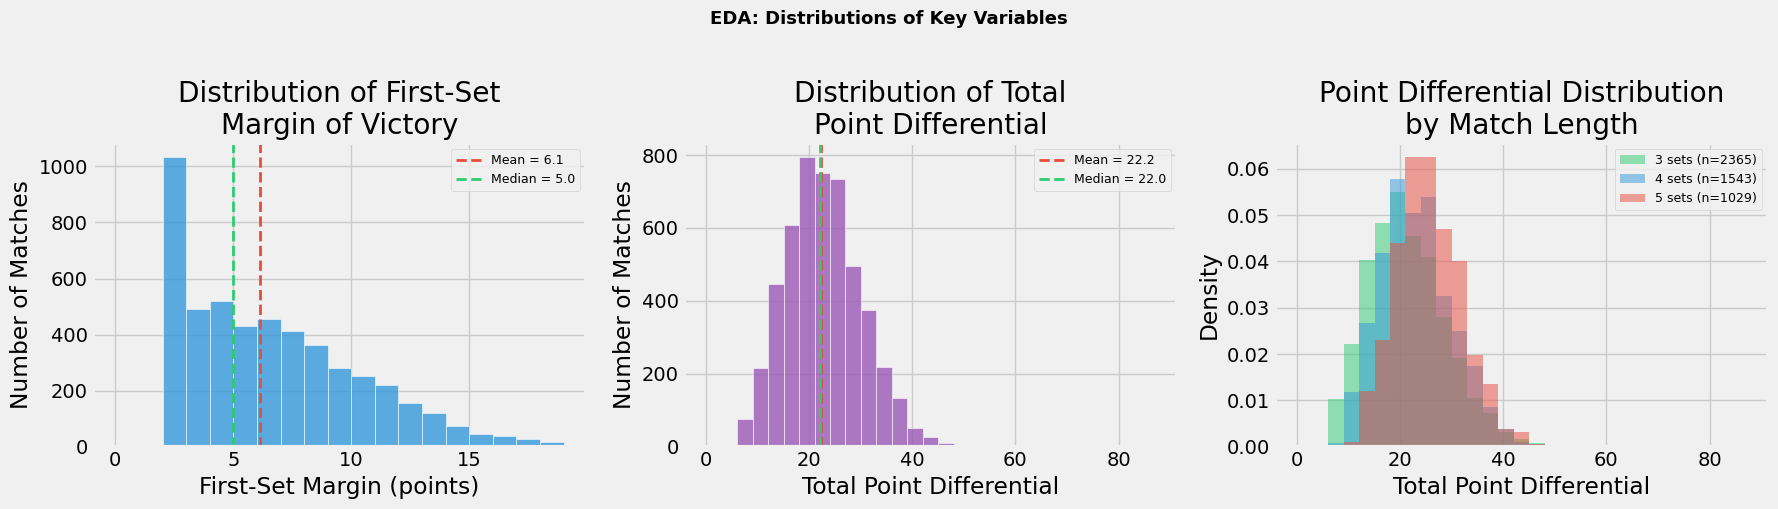

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(season['first_set_margin'], bins=np.arange(0, 20, 1), color='#3498db', 
        edgecolor='white', alpha=0.8)
ax.axvline(season['first_set_margin'].mean(), color='#e74c3c', linestyle='--', 
           linewidth=2, label=f'Mean = {season["first_set_margin"].mean():.1f}')
ax.axvline(season['first_set_margin'].median(), color='#2ecc71', linestyle='--', 
           linewidth=2, label=f'Median = {season["first_set_margin"].median():.1f}')
ax.set_xlabel('First-Set Margin (points)')
ax.set_ylabel('Number of Matches')
ax.set_title('Distribution of First-Set\nMargin of Victory')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(season['point_diff'], bins=np.arange(0, 90, 3), color='#9b59b6', 
        edgecolor='white', alpha=0.8)
ax.axvline(season['point_diff'].mean(), color='#e74c3c', linestyle='--', 
           linewidth=2, label=f'Mean = {season["point_diff"].mean():.1f}')
ax.axvline(season['point_diff'].median(), color='#2ecc71', linestyle='--', 
           linewidth=2, label=f'Median = {season["point_diff"].median():.1f}')
ax.set_xlabel('Total Point Differential')
ax.set_ylabel('Number of Matches')
ax.set_title('Distribution of Total\nPoint Differential')
ax.legend(fontsize=9)

ax = axes[2]
for n_sets, color, label in [(3, '#2ecc71', '3 sets'), (4, '#3498db', '4 sets'), (5, '#e74c3c', '5 sets')]:
    subset = season[season['total_sets'] == n_sets]['point_diff']
    ax.hist(subset, bins=np.arange(0, 90, 3), alpha=0.5, color=color, 
            label=f'{label} (n={len(subset)})', density=True)
ax.set_xlabel('Total Point Differential')
ax.set_ylabel('Density')
ax.set_title('Point Differential Distribution\nby Match Length')
ax.legend(fontsize=9)

plt.suptitle('EDA: Distributions of Key Variables', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The histograms above reveal several important observations about our data:

* First-set margin is right-skewed with most matches decided by 2–6 points in the first set. Very large margins (10+) are rare, indicating that first sets are generally competitive.
* Total point differential is also right-skewed, with a long tail of blowout matches. The mean is pulled higher than the median, confirming the skew.
* Breakdown by match length shows that 3-set matches (sweeps) have a different distribution shape than 4 and 5-set matches. Sweeps tend to have higher point differentials (less competitive), while extended matches cluster at lower differentials. This makes sense because closer matches take more sets to resolve.

## Correlation Overview

To get a high-level view of how our variables relate to each other before diving into specific research questions, we compute a correlation heatmap. This lets us quickly spot which variables are associated and how strongly, guiding where to focus our deeper analysis.

In [10]:
corr_vars = ['total_sets', 'first_set_margin', 'point_diff', 'first_set_winner_won_match']
corr_labels = ['Total Sets', 'First-Set Margin', 'Point Differential', 'FSW Won Match']

corr_matrix = season[corr_vars].corr()

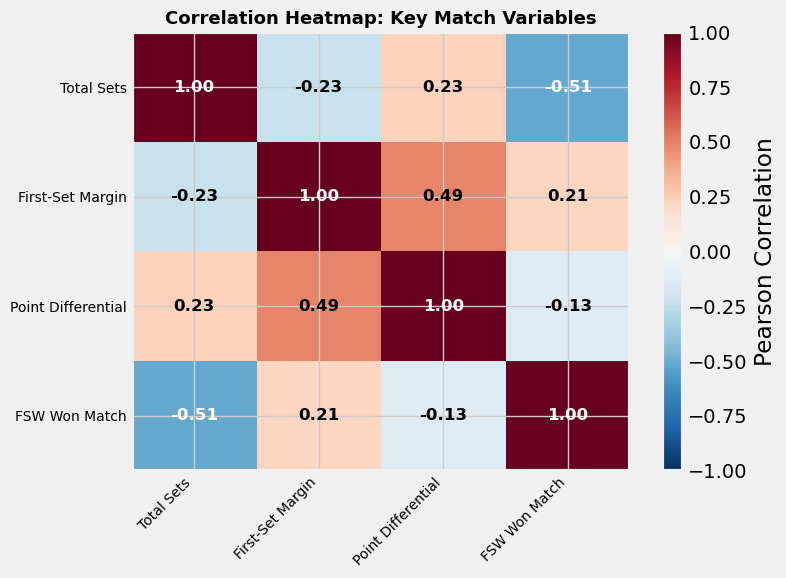

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(corr_labels)))
ax.set_yticklabels(corr_labels, fontsize=10)

for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_matrix.values[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                fontsize=12, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_title('Correlation Heatmap: Key Match Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation heatmap reveals some expected and some interesting relationships:

* Total sets vs. point differential has a weak negative correlation: matches that go to more sets tend to have slightly lower total point differentials, but the effect is modest. This makes sense as extended matches are more competitive.
* First-set margin vs. FSW won match shows a positive correlation: larger first-set victories are associated with a higher chance of winning the overall match. This motivates our investigation of margin effects in the analysis below.
* Total sets vs. FSW won match has a negative correlation: in longer matches, the first-set advantage weakens, which aligns with our hypothesis that extended matches are more uncertain.

With these baseline patterns established, we now proceed to our formal analysis of each research question.

# Data Analysis and Results

## Research Question 1: First-Set Advantage in Extended Matches (Regular Season)

We begin by examining how often the team that wins the first set goes on to win the match, broken down by the total number of sets played. Our focus is on extended matches (4 and 5 sets), where the contest was close enough that neither team swept.

We use a colored bar chart for this initial breakdown because it clearly shows the count and proportion in each category. Bar charts are the most appropriate choice here since we are comparing frequencies across a small number of discrete categories (3-, 4-, and 5-set matches).

Match length distribution (regular season):
  3-set matches: 2365 (47.9%)
  4-set matches: 1543 (31.3%)
  5-set matches: 1029 (20.8%)


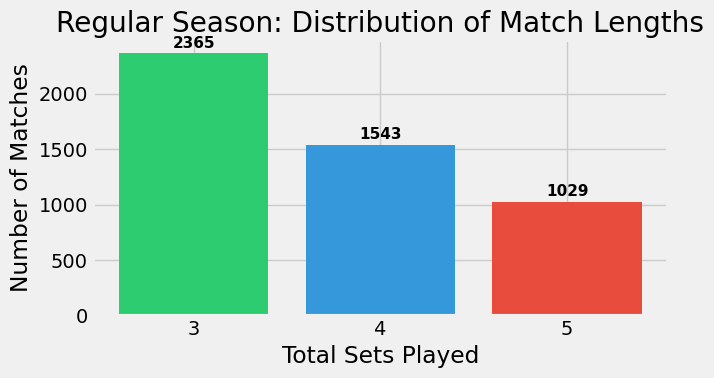

In [12]:
set_counts = season['total_sets'].value_counts().sort_index()
print("Match length distribution (regular season):")
for sets, count in set_counts.items():
    print(f"  {sets}-set matches: {count} ({count/len(season):.1%})")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(set_counts.index.astype(str), set_counts.values, color=['#2ecc71', '#3498db', '#e74c3c'])
ax.set_xlabel('Total Sets Played')
ax.set_ylabel('Number of Matches')
ax.set_title('Regular Season: Distribution of Match Lengths')
for bar, val in zip(bars, set_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

The majority of regular-season matches end in 3 sets (a sweep), meaning one team was dominant enough to win three straight. Four and five-set matches represent the more competitive contests. Understanding how many matches fall into each category is important because our primary research question focuses specifically on the extended matches, the subset where both teams were competitive enough to push beyond three sets.

This breakdown also tells us how much data we have for each comparison. With thousands of extended matches in the regular season, we have strong statistical power for our hypothesis tests.

In [13]:
win_rates = season.groupby('total_sets')['first_set_winner_won_match'].agg(['sum', 'count'])
win_rates.columns = ['wins', 'total']
win_rates['losses'] = win_rates['total'] - win_rates['wins']
win_rates['win_rate'] = win_rates['wins'] / win_rates['total']
print("Regular Season: First-set winner match outcomes by match length")
print(win_rates)
print(f"\nOverall first-set winner win rate: {season['first_set_winner_won_match'].mean():.1%}")

Regular Season: First-set winner match outcomes by match length
            wins  total  losses  win_rate
total_sets                               
3           2364   2365       1  0.999577
4           1028   1543     515  0.666235
5            499   1029     530  0.484937

Overall first-set winner win rate: 78.8%


The table above shows the raw counts and win rates. In 3-set matches (sweeps), the first-set winner nearly always wins, which is expected, since winning the first set in a sweep means you were dominant from the start. The more interesting question is whether this advantage persists in the 4- and 5-set matches where the outcome was much less certain.

Notice the sharp drop in win rate from 3-set matches (near 100%) to 4-set matches (67%) and then to 5-set matches (49%). This suggests that the longer a match goes, the less the first set matters. We will test whether these rates are statistically different from 50% (pure coin flip) using binomial tests below.

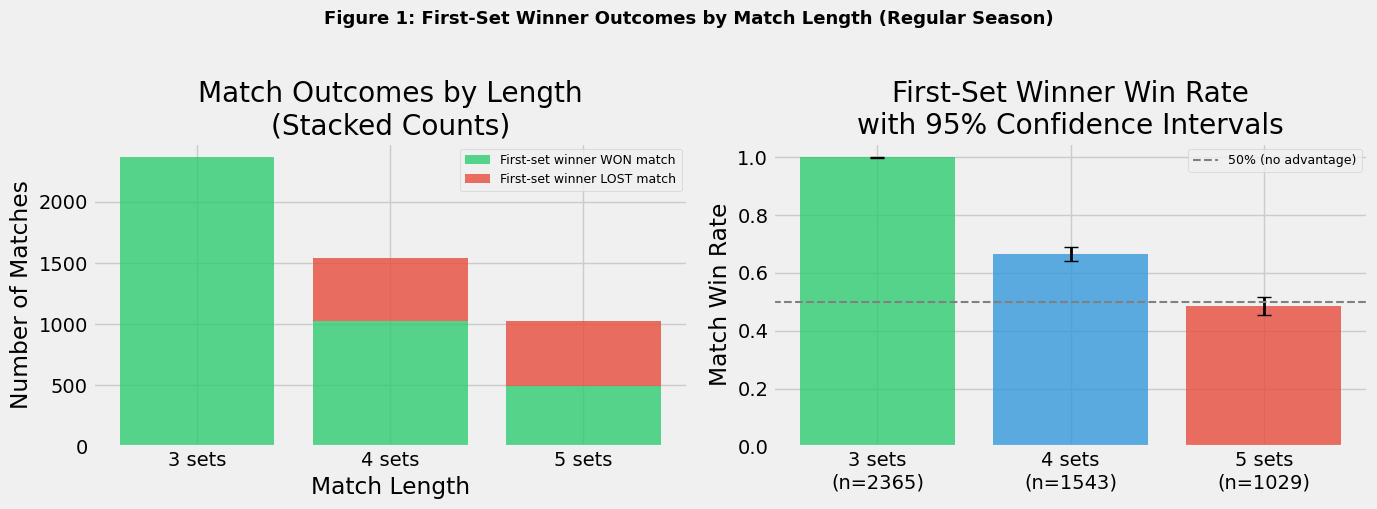

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_palette = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']

ax = axes[0]
x = np.arange(len(win_rates))
ax.bar(x, win_rates['wins'], label='First-set winner WON match', color='#2ecc71', alpha=0.8)
ax.bar(x, win_rates['losses'], bottom=win_rates['wins'], label='First-set winner LOST match', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{s} sets' for s in win_rates.index])
ax.set_xlabel('Match Length')
ax.set_ylabel('Number of Matches')
ax.set_title('Match Outcomes by Length\n(Stacked Counts)')
ax.legend(fontsize=9)

ax = axes[1]
for i, (sets, row) in enumerate(win_rates.iterrows()):
    p = row['win_rate']
    n = row['total']
    ci = stats.binomtest(int(row['wins']), int(n), p=0.5).proportion_ci(confidence_level=0.95, method='wilson')
    ax.bar(i, p, color=colors_palette[i % len(colors_palette)], alpha=0.8)
    ax.errorbar(i, p, yerr=[[p - ci.low], [ci.high - p]], fmt='none', color='black', capsize=5, linewidth=2)

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='50% (no advantage)')
ax.set_xticks(range(len(win_rates)))
ax.set_xticklabels([f'{s} sets\n(n={int(win_rates.loc[s, "total"])})' for s in win_rates.index])
ax.set_ylabel('Match Win Rate')
ax.set_title('First-Set Winner Win Rate\nwith 95% Confidence Intervals')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

plt.suptitle('Figure 1: First-Set Winner Outcomes by Match Length (Regular Season)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 1** presents the match outcomes by length. The left panel shows the raw counts: in 3-set sweeps, first-set winners overwhelmingly won, while in 4- and 5-set matches the split is more even. The right panel is more informative: it shows the win rate with 95% Wilson confidence intervals. The key question is whether the confidence intervals for extended matches lie entirely above the 50% line (gray dashed). If so, we have evidence that the first-set advantage is real and not just noise.

Looking at the right panel, we can see that the 4-set confidence interval sits clearly above 50%, while the 5-set interval overlaps with 50%. This visual preview suggests that the first-set advantage may only be meaningful in 4-set matches, a finding we will confirm statistically next.

In [15]:
print("=== Binomial Tests: First-Set Winner Win Rate > 50%? (Regular Season) ===\n")

for label, subset in [("All extended (4-5 sets)", season[season['extended_match']]),
                       ("4-set matches only", season[season['total_sets'] == 4]),
                       ("5-set matches only", season[season['total_sets'] == 5])]:
    n = len(subset)
    w = int(subset['first_set_winner_won_match'].sum())
    rate = w / n
    bt = stats.binomtest(w, n, p=0.5, alternative='greater')
    ci = bt.proportion_ci(confidence_level=0.95, method='wilson')
    print(f"{label}:")
    print(f"  n = {n}, wins = {w}, win rate = {rate:.1%}")
    print(f"  95% CI: [{ci.low:.3f}, {ci.high:.3f}]")
    print(f"  p-value = {bt.pvalue:.6f} {'***' if bt.pvalue < 0.001 else '**' if bt.pvalue < 0.01 else '*' if bt.pvalue < 0.05 else '(n.s.)'}")
    print()

=== Binomial Tests: First-Set Winner Win Rate > 50%? (Regular Season) ===

All extended (4-5 sets):
  n = 2572, wins = 1527, win rate = 59.4%
  95% CI: [0.578, 1.000]
  p-value = 0.000000 ***

4-set matches only:
  n = 1543, wins = 1028, win rate = 66.6%
  95% CI: [0.646, 1.000]
  p-value = 0.000000 ***

5-set matches only:
  n = 1029, wins = 499, win rate = 48.5%
  95% CI: [0.459, 1.000]
  p-value = 0.840755 (n.s.)



### Why Binomial Tests?

The binomial test is the appropriate choice here because we are testing a simple question: is the proportion of first-set winners who go on to win the match significantly greater than 50%, what we'd expect by chance alone? The test models each match as an independent trial, the first-set winner either wins or loses the match.

We report Wilson confidence intervals rather than standard Wald intervals because Wilson intervals perform better when the sample proportion is far from 0.5 or when sample sizes are moderate. A significant result (p < 0.05) would confirm that first-set advantage carries meaningful predictive power even in closely contested matches.

### Deeper Dive: Does the Margin of the First-Set Win Matter?

Beyond simply winning the first set, we might expect that teams who win the first set decisively (by a large margin) carry a stronger advantage into subsequent sets. We now examine whether first-set margin of victory correlates with match outcome in extended matches.

In [16]:
ext_season = season[season['extended_match']].copy()

ext_season['margin_bin'] = pd.cut(ext_season['first_set_margin'], 
                                   bins=[0, 3, 6, 10, 30],
                                   labels=['Narrow (1-3)', 'Moderate (4-6)', 'Decisive (7-10)', 'Blowout (11+)'],
                                   right=True)

margin_rates = ext_season.groupby('margin_bin', observed=True)['first_set_winner_won_match'].agg(['mean', 'count'])
margin_rates.columns = ['win_rate', 'n_matches']
print("First-set margin vs match win rate (extended matches, regular season):")
print(margin_rates)
print(f"\nCorrelation (first-set margin vs match win): "
      f"{ext_season['first_set_margin'].corr(ext_season['first_set_winner_won_match'].astype(int)):.4f}")

First-set margin vs match win rate (extended matches, regular season):
                 win_rate  n_matches
margin_bin                          
Narrow (1-3)     0.517875        979
Moderate (4-6)   0.567636        791
Decisive (7-10)  0.700658        608
Blowout (11+)    0.747423        194

Correlation (first-set margin vs match win): 0.1703


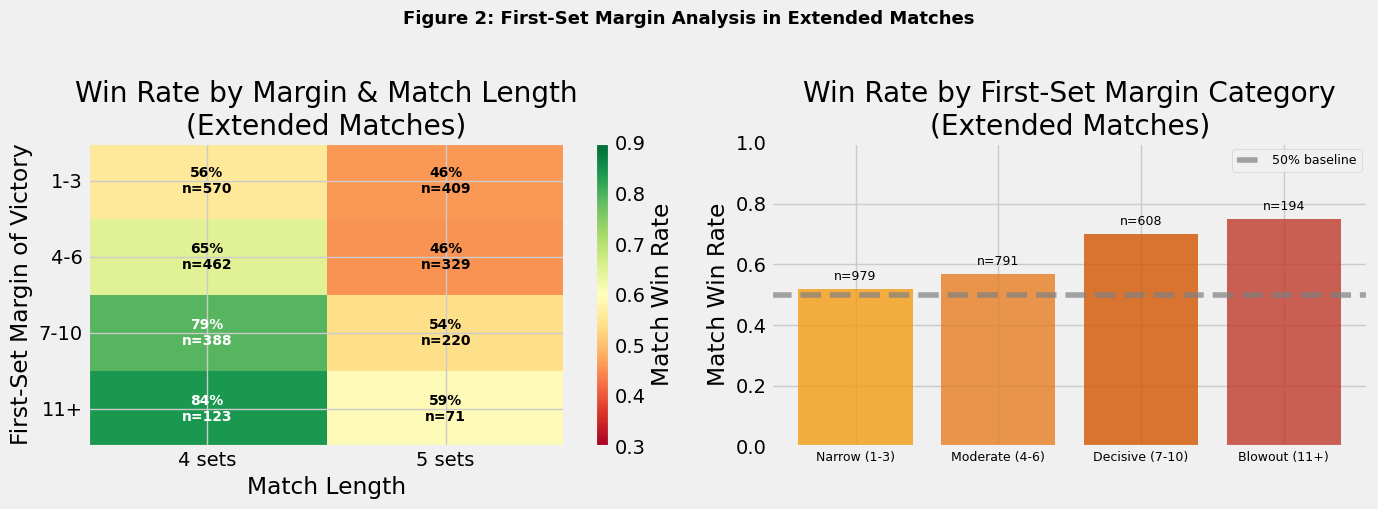

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ext = ext_season.copy()
ext['margin_bin'] = pd.cut(ext['first_set_margin'], bins=[0, 3, 6, 10, 30], 
                           labels=['1-3', '4-6', '7-10', '11+'])
heatmap_data = ext.groupby(['margin_bin', 'total_sets'])['first_set_winner_won_match'].mean().unstack(fill_value=0)

im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0.3, vmax=0.9)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f'{s} sets' for s in heatmap_data.columns])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel('Match Length')
ax.set_ylabel('First-Set Margin of Victory')
ax.set_title('Win Rate by Margin & Match Length\n(Extended Matches)')

counts = ext.groupby(['margin_bin', 'total_sets'])['first_set_winner_won_match'].count().unstack(fill_value=0)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        n = int(counts.values[i, j])
        text_color = 'white' if val > 0.7 or val < 0.4 else 'black'
        ax.text(j, i, f'{val:.0%}\nn={n}', ha='center', va='center', 
                fontsize=10, fontweight='bold', color=text_color)
plt.colorbar(im, ax=ax, label='Match Win Rate')

ax = axes[1]
x = np.arange(len(margin_rates))
colors_bar = ['#f39c12', '#e67e22', '#d35400', '#c0392b']
bars = ax.bar(x, margin_rates['win_rate'], color=colors_bar, alpha=0.8)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% baseline')
ax.set_xticks(x)
ax.set_xticklabels(margin_rates.index, fontsize=9)
ax.set_ylabel('Match Win Rate')
ax.set_title('Win Rate by First-Set Margin Category\n(Extended Matches)')
ax.set_ylim(0, 1)
for bar, (_, row) in zip(bars, margin_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'n={int(row["n_matches"])}', ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=9)

plt.suptitle('Figure 2: First-Set Margin Analysis in Extended Matches',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 2** explores first-set margin in extended matches. The left panel is a heatmap that cross-tabulates first-set margin bins (rows) against match length (columns), with each cell colored by the first-set winner's match win rate. This allows us to see at a glance whether larger first-set margins correspond to higher win rates, and whether this effect differs between 4- and 5-set matches. The right panel presents the same data as a colored bar chart grouped by margin category, making it easy to compare win rates across bins.

The takeaway is that the advantage is graded, not binary. Teams that barely win the first set have a much smaller edge than teams that win it convincingly. This makes sense because a narrow first-set win (like 26-24) suggests the teams are very evenly matched, while a blowout (like 25-15) suggests one team is clearly stronger.

### Chi-Square Test: Independence of First-Set Outcome and Match Outcome

We use a chi-square test of independence to evaluate whether the first-set outcome and the match outcome are statistically related in extended matches. This complements the binomial test by testing the association in a contingency table rather than just testing a proportion against 50%.

Why this test? The chi-square test is designed for categorical data organized in a contingency table. Our two variables (won/lost first set, won/lost match) are both categorical, making this the best test for association.

In [18]:
ext = season[season['extended_match']]

won_match = ext['first_set_winner_won_match'].sum()
lost_match = len(ext) - won_match
contingency = np.array([[won_match, lost_match],
                         [lost_match, won_match]])

print("Contingency Table (extended matches, regular season):")
print(pd.DataFrame(contingency,
                    index=['Won 1st Set', 'Lost 1st Set'],
                    columns=['Won Match', 'Lost Match']))

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_val:.6f}")
print(f"Expected frequencies (under independence):\n{expected}")

Contingency Table (extended matches, regular season):
              Won Match  Lost Match
Won 1st Set        1527        1045
Lost 1st Set       1045        1527

Chi-square statistic: 179.9075
Degrees of freedom: 1
p-value: 0.000000
Expected frequencies (under independence):
[[1286. 1286.]
 [1286. 1286.]]


The chi-square test tells us whether first-set outcome and match outcome are independent. If the p-value is below 0.05, we reject independence, meaning winning the first set is associated with winning the match even in these extended contests. The expected frequencies show what we'd expect if there were no relationship; large differences between observed and expected values drive the chi-square statistic upward.

In other terms, if the first set didn't matter at all, we'd expect the "Won 1st Set / Won Match" cell and the "Won 1st Set / Lost Match" cell to have roughly equal counts. The chi-square test measures how far the actual counts deviate from this equal-split expectation.

### Set-by-Set Competitiveness Analysis

To understand how matches unfold after the first set, we track the average set-by-set point differential from the perspective of the first-set winner. If the first-set advantage carries forward, we would expect the first-set winner to maintain a positive differential in later sets. If the advantage fades, the differential should drop toward zero or turn negative, indicating increasing competitiveness as the match progresses.

Why line plots? We use line plots here because the x-axis (set number) represents an ordered sequence. Lines naturally convey the trajectory and shifts in competitiveness from one set to the next, making it easy to spot where the first-set winner's advantage grows, shrinks, or reverses. We split by match outcome (won vs. lost the match) to compare the trajectories, and include 95% confidence interval error bars to show the uncertainty around each mean.

In [19]:
ext = season[season['extended_match']].copy()

team1_won_first = ext['first_set_winner'] == ext['team1']
for i in range(1, 6):
    raw_diff = ext[f'set{i}_diff']
    ext[f'fsw_set{i}_diff'] = np.where(team1_won_first, raw_diff, -raw_diff)

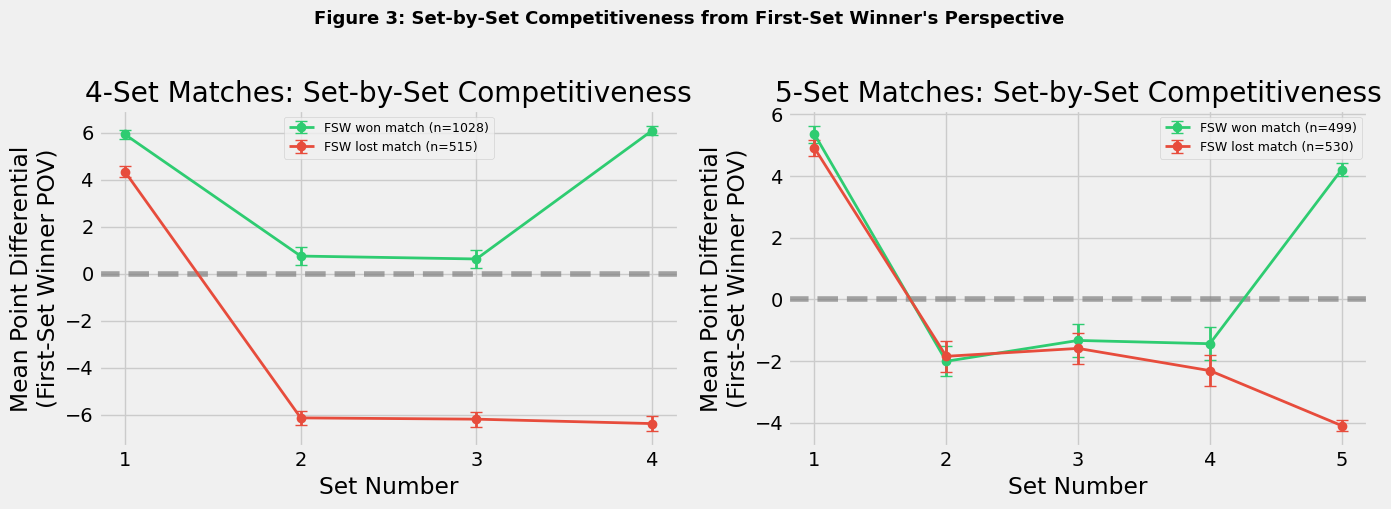

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, n_sets, title in zip(axes, [4, 5], ['4-Set Matches', '5-Set Matches']):
    sub = ext[ext['total_sets'] == n_sets]
    sets_range = range(1, n_sets + 1)
    
    for outcome, color, label in [(True, '#2ecc71', 'FSW won match'), 
                                   (False, '#e74c3c', 'FSW lost match')]:
        group = sub[sub['first_set_winner_won_match'] == outcome]
        means = [group[f'fsw_set{i}_diff'].mean() for i in sets_range]
        sems = [group[f'fsw_set{i}_diff'].sem() for i in sets_range]
        ax.errorbar(list(sets_range), means, yerr=[1.96*s for s in sems],
                    marker='o', linewidth=2, capsize=4, label=f'{label} (n={len(group)})',
                    color=color)
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
    ax.set_xlabel('Set Number')
    ax.set_ylabel('Mean Point Differential\n(First-Set Winner POV)')
    ax.set_title(f'{title}: Set-by-Set Competitiveness')
    ax.set_xticks(list(sets_range))
    ax.legend(fontsize=9)

plt.suptitle('Figure 3: Set-by-Set Competitiveness from First-Set Winner\'s Perspective',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 3** tracks set-by-set competitiveness. These line plots reveal how point differentials evolve across sets from the first-set winner's perspective. Both lines start positive in set 1 (by definition), but then diverge: in matches the first-set winner ultimately won (green), the differential tends to recover in later sets, while in matches they lost (red), the opponent claws back in the middle sets. The error bars show 95% confidence intervals around the mean.

What to look for: in 4-set matches, the green line stays above zero throughout, meaning the first-set winner maintained their scoring edge across all sets. In 5-set matches, both lines converge toward zero by the deciding set, suggesting neither team has a meaningful scoring advantage by that point. This visual pattern is consistent with our earlier finding that first-set advantage disappears in 5-set matches.

## Research Question 2: Away Team First-Set Win and Match Competitiveness (Regular Season)

We now investigate whether matches where the away team wins the first set tend to be more competitive. Our competitiveness metric is total point differential, the sum of absolute point differences across all played sets. A lower point differential indicates a closer, more competitive match overall.

We restrict this analysis to regular-season matches where home/away status is determinable (site column contains "@").

Why histograms and boxplots for this comparison? We use overlaid histograms to compare the full shape of the two distributions (home vs. away first-set winner), and boxplots to summarize key statistics (median, IQR, outliers) side by side. The histogram and boxplot combination lets us visually assess whether the distributions differ before running any tests.

In [21]:
ha_season = season[season['site'].str.contains('@')].copy()

away_first = ha_season[ha_season['first_set_winner_is_away']]
home_first = ha_season[~ha_season['first_set_winner_is_away']]

print(f"Regular season matches with home/away info: {len(ha_season)}")
print(f"  Home team won first set: {len(home_first)} ({len(home_first)/len(ha_season):.1%})")
print(f"  Away team won first set: {len(away_first)} ({len(away_first)/len(ha_season):.1%})")

Regular season matches with home/away info: 979
  Home team won first set: 518 (52.9%)
  Away team won first set: 461 (47.1%)


In [22]:
print(f"\n--- Point Differential Summary ---")
print(f"  Home won 1st set: mean = {home_first['point_diff'].mean():.2f}, "
      f"median = {home_first['point_diff'].median():.1f}, std = {home_first['point_diff'].std():.2f}")
print(f"  Away won 1st set: mean = {away_first['point_diff'].mean():.2f}, "
      f"median = {away_first['point_diff'].median():.1f}, std = {away_first['point_diff'].std():.2f}")
print(f"\n  Difference in means: {home_first['point_diff'].mean() - away_first['point_diff'].mean():.2f} points")


--- Point Differential Summary ---
  Home won 1st set: mean = 22.25, median = 22.0, std = 7.07
  Away won 1st set: mean = 22.65, median = 23.0, std = 7.37

  Difference in means: -0.40 points


The split between home and away first-set winners already tells a lot. Home teams win the first set more often, reflecting the well-documented home-court advantage in volleyball. The key comparison here is the point differential. If the away team winning the first set signals a more evenly matched contest, we should see lower point differentials in those matches.

Looking at the means and medians above, we can get an initial sense of whether there's a meaningful difference before we run any formal tests.

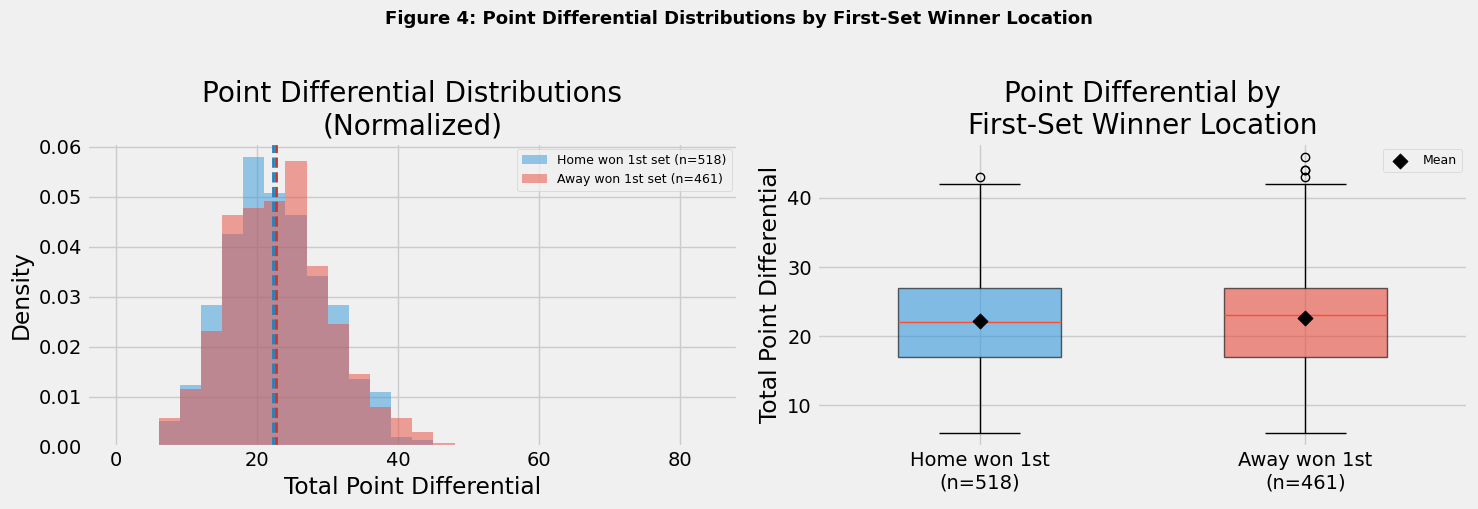

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
bins = np.arange(0, 85, 3)
ax.hist(home_first['point_diff'], bins=bins, alpha=0.5, density=True, 
        label=f'Home won 1st set (n={len(home_first)})', color='#3498db')
ax.hist(away_first['point_diff'], bins=bins, alpha=0.5, density=True,
        label=f'Away won 1st set (n={len(away_first)})', color='#e74c3c')
ax.axvline(home_first['point_diff'].mean(), color='#2980b9', linestyle='--', linewidth=2)
ax.axvline(away_first['point_diff'].mean(), color='#c0392b', linestyle='--', linewidth=2)
ax.set_xlabel('Total Point Differential')
ax.set_ylabel('Density')
ax.set_title('Point Differential Distributions\n(Normalized)')
ax.legend(fontsize=9)

ax = axes[1]
bp = ax.boxplot([home_first['point_diff'], away_first['point_diff']],
                labels=[f'Home won 1st\n(n={len(home_first)})', 
                        f'Away won 1st\n(n={len(away_first)})'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.6)

means = [home_first['point_diff'].mean(), away_first['point_diff'].mean()]
ax.scatter([1, 2], means, marker='D', color='black', s=60, zorder=5, label='Mean')
ax.set_ylabel('Total Point Differential')
ax.set_title('Point Differential by\nFirst-Set Winner Location')
ax.legend(fontsize=9)

plt.suptitle('Figure 4: Point Differential Distributions by First-Set Winner Location',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 4** compares the point differential distributions between matches where the home team won the first set and matches where the away team won the first set. The left panel shows overlaid histograms (normalized to density) so we can compare the shapes despite unequal group sizes. Dashed vertical lines mark each group's mean. If the away-first-set-win mean is lower, it suggests those matches tend to be more competitive. The right panel shows a boxplot comparison that summarizes the central tendency, spread, and outliers of each group side by side. Diamond markers indicate the group means.

At a glance, the two distributions look remarkably similar. The means are close together and the overall shapes overlap heavily. This visual similarity foreshadows what the statistical test will confirm: there is no meaningful difference in competitiveness between home and away first-set winners.

In [24]:
print("=== Permutation Test: Away vs Home First-Set Winner Point Differentials ===\n")

observed_diff = home_first['point_diff'].mean() - away_first['point_diff'].mean()
print(f"Observed difference in means (home - away): {observed_diff:.2f} points")

=== Permutation Test: Away vs Home First-Set Winner Point Differentials ===

Observed difference in means (home - away): -0.40 points


In [25]:
combined = np.concatenate([home_first['point_diff'].values, away_first['point_diff'].values])
n_home = len(home_first)
n_perms = 10000
np.random.seed(42)

perm_diffs = np.empty(n_perms)
for i in range(n_perms):
    np.random.shuffle(combined)
    perm_diffs[i] = combined[:n_home].mean() - combined[n_home:].mean()

In [26]:
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f"Permutation test p-value (two-sided): {p_value:.4f}")
print(f"{'Significant' if p_value < 0.05 else 'Not significant'} at alpha = 0.05")
print(f"\nInterpretation: The observed difference of {observed_diff:.2f} points is "
      f"{'unlikely' if p_value < 0.05 else 'easily'} explained by random chance alone.")

Permutation test p-value (two-sided): 0.3818
Not significant at alpha = 0.05

Interpretation: The observed difference of -0.40 points is easily explained by random chance alone.


### Why a Permutation Test?

A permutation test is a simple, assumption-free way to test whether two groups differ. The idea is that if home/away status truly doesn't matter, then shuffling the labels randomly should produce differences similar to what we observed. We shuffle the labels 10,000 times, compute the difference in means each time, and check how often the random differences are as large as our observed difference. If our observed difference falls well within the range of random shuffles, we conclude it's not statistically significant.

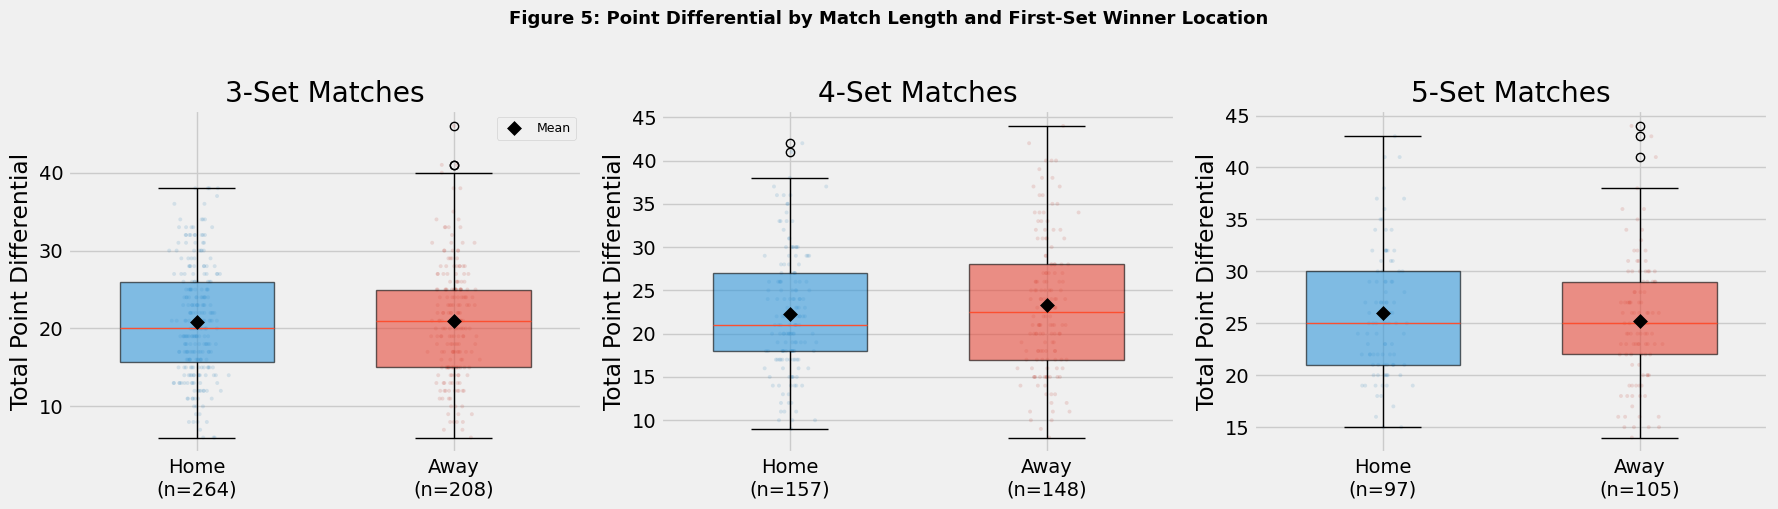

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n_sets in zip(axes, [3, 4, 5]):
    home_sub = home_first[home_first['total_sets'] == n_sets]['point_diff']
    away_sub = away_first[away_first['total_sets'] == n_sets]['point_diff']
    
    bp = ax.boxplot([home_sub, away_sub],
                     labels=[f'Home\n(n={len(home_sub)})', f'Away\n(n={len(away_sub)})'],
                     patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.6)
    
    for i, (data, color) in enumerate([(home_sub, '#2980b9'), (away_sub, '#c0392b')]):
        jitter = np.random.normal(0, 0.04, size=len(data))
        ax.scatter(np.full(len(data), i + 1) + jitter, data, 
                   alpha=0.15, s=8, color=color, edgecolors='none')
    
    ax.set_ylabel('Total Point Differential')
    ax.set_title(f'{n_sets}-Set Matches')
    
    ax.scatter([1, 2], [home_sub.mean(), away_sub.mean()], 
               marker='D', color='black', s=50, zorder=5, label='Mean')
    if n_sets == 3:
        ax.legend(fontsize=9)

plt.suptitle('Figure 5: Point Differential by Match Length and First-Set Winner Location', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 5** breaks down the home vs. away comparison by match length. We use boxplots here because they provide a concise visual summary of each distribution's center, spread, and outliers. Each individual data point is shown as a semi-transparent dot (jittered horizontally to reduce overlap), while the box shows the interquartile range and the black diamond marks the mean.

Why stratify by match length? This is important because the overall comparison (across all match lengths) could be confounded by match length. If away first-set winners happen to play more extended matches, the average point differential might differ for structural reasons rather than competitiveness. Looking at each match length separately removes that potential confound and gives us a cleaner comparison.

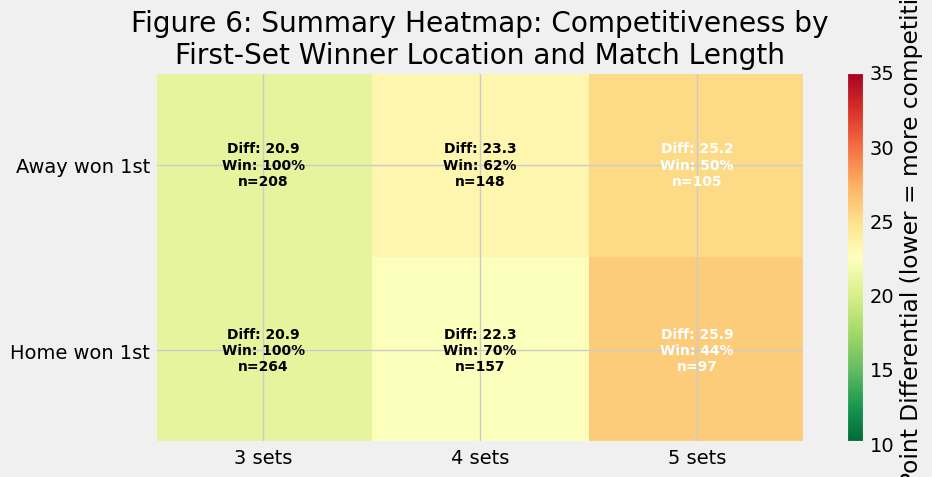

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

categories = []
for location, group, label in [('Home', home_first, 'Home won 1st'),
                                 ('Away', away_first, 'Away won 1st')]:
    for n_sets in [3, 4, 5]:
        sub = group[group['total_sets'] == n_sets]
        categories.append({
            'Location': label,
            'Sets': f'{n_sets} sets',
            'FSW Win Rate': sub['first_set_winner_won_match'].mean(),
            'Mean Pt Diff': sub['point_diff'].mean(),
            'Count': len(sub)
        })

summary = pd.DataFrame(categories)
pivot_rate = summary.pivot(index='Location', columns='Sets', values='FSW Win Rate')
pivot_diff = summary.pivot(index='Location', columns='Sets', values='Mean Pt Diff')
pivot_count = summary.pivot(index='Location', columns='Sets', values='Count')

im = ax.imshow(pivot_diff.values, cmap='RdYlGn_r', aspect='auto', vmin=10, vmax=35)
ax.set_xticks(range(len(pivot_diff.columns)))
ax.set_xticklabels(pivot_diff.columns)
ax.set_yticks(range(len(pivot_diff.index)))
ax.set_yticklabels(pivot_diff.index)

for i in range(len(pivot_diff.index)):
    for j in range(len(pivot_diff.columns)):
        diff_val = pivot_diff.values[i, j]
        rate_val = pivot_rate.values[i, j]
        count_val = int(pivot_count.values[i, j])
        ax.text(j, i, f'Diff: {diff_val:.1f}\nWin: {rate_val:.0%}\nn={count_val}',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if diff_val > 25 else 'black')

plt.colorbar(im, ax=ax, label='Mean Point Differential (lower = more competitive)')
ax.set_title('Figure 6: Summary Heatmap: Competitiveness by\nFirst-Set Winner Location and Match Length')
plt.tight_layout()
plt.show()

**Figure 6** (the heatmap) provides a compact summary of both research questions simultaneously, broken down by match length and first-set winner location. Each cell shows three pieces of information: the mean point differential (color-coded so greener = more competitive), the first-set winner's match win rate, and the sample size.

This single visualization lets us see the full picture at once. Notice that within each match length, the home and away rows look very similar, reinforcing the RQ2 finding that home/away status does not meaningfully affect competitiveness. Meanwhile, the columns show the expected pattern of 3-set matches having the highest point differentials (least competitive), while 5-set matches are the closest.

## Tournament Validation

We now test whether the patterns found in the regular season hold up in the 2019 NCAA tournament. The tournament is a single-elimination bracket with only 63 matches, so we cannot achieve the same statistical power. Instead, we treat this as a directional consistency check. Do the tournament results align with the regular-season findings, even if the small sample prevents statistical significance?

Why validate with tournament data? Using a separate dataset (the tournament) to check our regular-season findings guards against overfitting our conclusions to one particular dataset. If the same patterns appear in both the regular season (large sample, high power) and the tournament (small sample, different competitive context), we can be more confident that the effects are real and generalizable rather than artifacts of a specific dataset.

In [29]:
t_set_counts = tournament['total_sets'].value_counts().sort_index()
print("Tournament match length distribution:")
for sets, count in t_set_counts.items():
    print(f"  {sets}-set matches: {count} ({count/len(tournament):.1%})")

Tournament match length distribution:
  3-set matches: 38 (60.3%)
  4-set matches: 12 (19.0%)
  5-set matches: 13 (20.6%)


In [30]:
t_win_rates = tournament.groupby('total_sets')['first_set_winner_won_match'].agg(['mean', 'sum', 'count'])
t_win_rates.columns = ['win_rate', 'wins', 'total']
print(f"\nTournament: First-set winner win rates by match length:")
print(t_win_rates)
print(f"\nOverall tournament first-set winner win rate: {tournament['first_set_winner_won_match'].mean():.1%}")


Tournament: First-set winner win rates by match length:
            win_rate  wins  total
total_sets                       
3           1.000000    38     38
4           0.500000     6     12
5           0.538462     7     13

Overall tournament first-set winner win rate: 81.0%


The tournament has a relatively higher proportion of extended matches compared to the regular season, which makes sense since tournament teams are more evenly matched (all qualified for the championship bracket), so fewer matches end in sweeps.

This is encouraging for our validation because we have enough extended matches in the tournament to make at least a rough directional comparison with the regular season, even if the small overall sample prevents strong statistical conclusions.

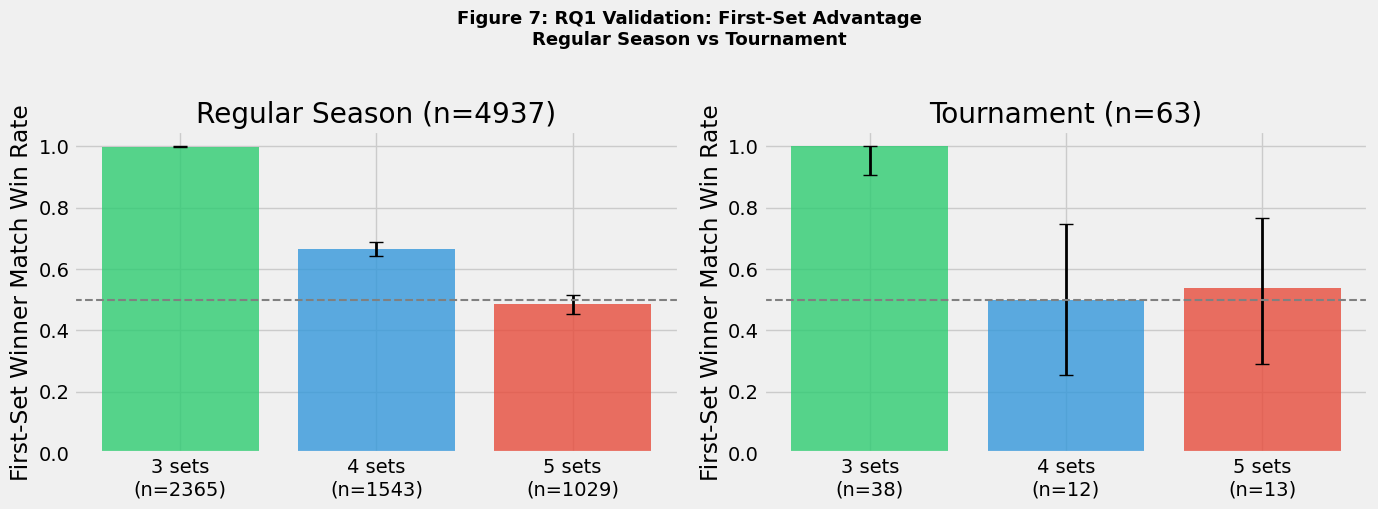

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_palette = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']

for ax, data, title in zip(axes, [season, tournament], ['Regular Season (n={})'.format(len(season)), 
                                                          'Tournament (n={})'.format(len(tournament))]):
    wr = data.groupby('total_sets')['first_set_winner_won_match'].agg(['mean', 'sum', 'count'])
    wr.columns = ['win_rate', 'wins', 'total']
    
    for i, (sets, row) in enumerate(wr.iterrows()):
        p = row['win_rate']
        n = int(row['total'])
        w = int(row['wins'])
        ci = stats.binomtest(w, n, p=0.5).proportion_ci(confidence_level=0.95, method='wilson')
        ax.bar(i, p, color=colors_palette[i % len(colors_palette)], alpha=0.8)
        ax.errorbar(i, p, yerr=[[p - ci.low], [ci.high - p]], fmt='none', 
                     color='black', capsize=5, linewidth=2)
    
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.5)
    ax.set_xticks(range(len(wr)))
    ax.set_xticklabels([f'{s} sets\n(n={int(wr.loc[s, "total"])})' for s in wr.index])
    ax.set_ylabel('First-Set Winner Match Win Rate')
    ax.set_title(title)
    ax.set_ylim(0, 1.05)

plt.suptitle('Figure 7: RQ1 Validation: First-Set Advantage\nRegular Season vs Tournament',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figure 7** places the regular season and tournament side by side with identical axes, making it easy to compare. Note the much wider confidence intervals in the tournament panel, a direct consequence of the small sample size (63 matches vs. nearly 5,000). Even if the point estimates differ between season and tournament, overlapping confidence intervals would suggest the results are consistent.

The key question is not whether the tournament numbers exactly match the regular season, but whether they point in the same direction. If the tournament shows a similar pattern (high win rate in 3-set, moderate in 4-set, near 50% in 5-set), it supports the generalizability of our findings beyond just the regular season.

In [32]:
t_ext = tournament[tournament['extended_match']]
t_n = len(t_ext)
t_w = int(t_ext['first_set_winner_won_match'].sum())
t_rate = t_w / t_n if t_n > 0 else 0

print(f"Tournament extended matches: {t_n}")
print(f"First-set winner won: {t_w} ({t_rate:.1%})")

if t_n > 0:
    t_bt = stats.binomtest(t_w, t_n, p=0.5, alternative='greater')
    t_ci = t_bt.proportion_ci(confidence_level=0.95, method='wilson')
    print(f"Binomial test p-value: {t_bt.pvalue:.4f}")
    print(f"95% CI: [{t_ci.low:.3f}, {t_ci.high:.3f}]")
    print(f"\nNote: With only {t_n} extended matches, the test has low statistical power.")
    print(f"The direction of the effect ({'consistent' if t_rate > 0.5 else 'inconsistent'} "
          f"with regular season) is more informative than the p-value here.")

Tournament extended matches: 25
First-set winner won: 13 (52.0%)
Binomial test p-value: 0.5000
95% CI: [0.362, 1.000]

Note: With only 25 extended matches, the test has low statistical power.
The direction of the effect (consistent with regular season) is more informative than the p-value here.


With so few tournament extended matches, the p-value alone is not very informative. What matters more is directional consistency: whether the tournament first-set winner's win rate is above or below 50% in the same direction as the regular season. A consistent direction across both datasets strengthens our confidence in the finding, even without tournament-level significance.

Think of it like this. The regular season gives us the statistical power to detect real effects, and the tournament tells us whether those effects show up in a completely different competitive context.

In [33]:
ha_tourn = tournament[tournament['site'].str.contains('@')].copy()
t_away = ha_tourn[ha_tourn['first_set_winner_is_away']]
t_home = ha_tourn[~ha_tourn['first_set_winner_is_away']]

print(f"Tournament matches with home/away info: {len(ha_tourn)}")
print(f"  Home won 1st set: {len(t_home)}, mean pt diff = {t_home['point_diff'].mean():.2f}")
print(f"  Away won 1st set: {len(t_away)}, mean pt diff = {t_away['point_diff'].mean():.2f}")

if len(t_away) > 1 and len(t_home) > 1:
    direction = "consistent" if t_away['point_diff'].mean() < t_home['point_diff'].mean() else "inconsistent"
    print(f"\nDirection: {direction} with regular season")
    print(f"Note: With only {len(t_away)} away-first-set-win matches, formal testing is not meaningful.")
else:
    print("\nToo few matches in one group for comparison.")

Tournament matches with home/away info: 24
  Home won 1st set: 19, mean pt diff = 20.32
  Away won 1st set: 5, mean pt diff = 25.60

Direction: inconsistent with regular season
Note: With only 5 away-first-set-win matches, formal testing is not meaningful.


Tournament matches at neutral or hosted sites may have different dynamics than regular-season home/away games. Importantly, the NCAA tournament is played at pre-selected host sites, so the concept of "home" vs "away" is somewhat diluted compared to the regular season. Still, comparing the direction of the effect provides a useful sanity check.

In [34]:
print("=" * 70)
print("COMPREHENSIVE SUMMARY: Regular Season vs Tournament")
print("=" * 70)

for label, data in [("REGULAR SEASON", season), ("TOURNAMENT", tournament)]:
    print(f"\n--- {label} ({len(data)} matches) ---")

# RQ1
    overall = data['first_set_winner_won_match'].mean()
    ext = data[data['extended_match']]
    ext_rate = ext['first_set_winner_won_match'].mean() if len(ext) > 0 else float('nan')
    print(f"  First-set winner overall win rate: {overall:.1%}")
    print(f"  First-set winner win rate (extended): {ext_rate:.1%} (n={len(ext)})")

#RQ2
    ha = data[data['site'].str.contains('@')]
    if len(ha) > 0:
        away_diff = ha[ha['first_set_winner_is_away']]['point_diff'].mean()
        home_diff = ha[~ha['first_set_winner_is_away']]['point_diff'].mean()
        n_away = ha['first_set_winner_is_away'].sum()
        n_home = len(ha) - n_away
        print(f"  Pt diff (home won 1st): {home_diff:.1f} (n={n_home})")
        print(f"  Pt diff (away won 1st): {away_diff:.1f} (n={n_away})")
        print(f"  Difference: {home_diff - away_diff:+.1f} pts "
              f"({'away more competitive' if away_diff < home_diff else 'home more competitive'})")

print("\n" + "=" * 70)

COMPREHENSIVE SUMMARY: Regular Season vs Tournament

--- REGULAR SEASON (4937 matches) ---
  First-set winner overall win rate: 78.8%
  First-set winner win rate (extended): 59.4% (n=2572)
  Pt diff (home won 1st): 22.3 (n=518)
  Pt diff (away won 1st): 22.7 (n=461)
  Difference: -0.4 pts (home more competitive)

--- TOURNAMENT (63 matches) ---
  First-set winner overall win rate: 81.0%
  First-set winner win rate (extended): 52.0% (n=25)
  Pt diff (home won 1st): 20.3 (n=19)
  Pt diff (away won 1st): 25.6 (n=5)
  Difference: -5.3 pts (home more competitive)



This summary table puts all the key numbers side by side. The regular season provides our statistically powered results, while the tournament column shows whether those patterns hold directionally under high-stakes conditions. Consistency between the two datasets would be notable given that tournament matches feature stronger, more evenly matched teams playing under intense pressure, conditions that could plausibly disrupt regular-season patterns.

When reading this table, focus on whether the regular season and tournament columns tell the same story, rather than on the specific tournament p-values (which have low power due to small sample size).

## Ethics

## Data Privacy and Consent

The data used in this project consists entirely of publicly available NCAA Division I women's volleyball match results from the 2019 season. These are official game scores and outcomes that are part of the public record, published by the NCAA and various sports media outlets. No personally identifiable information about individual players, coaches, or spectators is included in the dataset. Our analysis is exclusively at the match level, examining team-level outcomes rather than individual performance metrics.

The team names and match results analyzed here are a matter of public record and do not raise privacy concerns. Attendance figures are aggregate counts that do not identify individual attendees. The site/venue information is publicly available.

## Analytical Integrity

We have been careful to present our statistical analysis honestly, applying several safeguards:

* Appropriate test selection: We used binomial tests for proportions, chi-square tests for categorical associations, and permutation tests for comparing group means, each matched to the type of data and question at hand.
* Confidence intervals: Wilson confidence intervals are reported for win rate estimates, providing a range of plausible values rather than a single point estimate.
* Separate validation dataset: Keeping the tournament data completely separate from the regular-season analysis helps guard against overfitting our conclusions to a single dataset.
* Non-significant results reported: We report all test results regardless of whether they support our hypotheses, avoiding publication bias.

## Potential Biases and Limitations

* Selection bias in venue coding: The @ prefix for away games may not capture all venue types. Neutral-site games are excluded from RQ2, which could bias the home/away comparison if neutral-site games systematically differ.
* Survivorship bias: By focusing on extended matches for RQ1, we condition on the match being competitive enough to go beyond 3 sets. This is a deliberate analytical choice, but it means our findings about first-set advantage apply specifically to competitive matches, not all matches.
* Single-season scope: The 2019 season may not be representative of all seasons. Rule changes, conference realignment, or pandemic-related disruptions in subsequent seasons could alter the patterns we observe.
* Ecological fallacy: We analyze team-level match outcomes, but individual player injuries, substitutions, and fatigue (which we cannot observe in this dataset) may drive the patterns we attribute to first-set advantage.

## Broader Impact

While our analysis is descriptive and retrospective, findings about first-set advantage could be used by coaching staffs to allocate resources differently across sets (e.g., resting key players in later sets after winning the first set, or pressing harder in the first set). We note that such strategic applications would require more granular data and causal analysis beyond what this observational study provides.

## Discusison and Conclusion

## Summary of Findings

#### Research Question 1: First-Set Advantage in Extended Matches

Our analysis reveals a clear but complex first-set advantage in the 2019 NCAA Division I Women's Volleyball regular season. Overall, the team that won the first set went on to win the match 78.8% of the time across all 4,937 matches. However, this headline number is heavily inflated by 3-set sweeps, where the first-set winner won 100% of the time, a guarunteed result, since sweeping 3-0 inherently means winning the first set.

The more meaningful finding concerns extended matches (4 and 5 sets), where neither team dominated. Here, the first-set advantage persists but varies dramatically by match length:

* In 4-set matches, the first-set winner won 66.6% of the time (1,028 of 1,543). A one-sided binomial test confirmed this is significantly above 50% (p < 0.001), with a 95% Wilson confidence interval. Winning the first set in a 4-set match confers a substantial and statistically robust advantage.
* In 5-set matches, the first-set winner won only 48.5% of the time (499 of 1,029), actually below 50%, though not significantly so (p = 0.84). In matches that go the full distance, the first-set advantage completely disappears.

This divergence between 4-set and 5-set matches tells a coherent story. In 4-set matches, the first-set winner typically maintains enough of an advantage to close out the match 3-1. But in 5-set matches, where the opponent fought back to force a deciding set, the first-set advantage has been completely disregarded. The chi-square test of independence confirmed a significant association between first-set outcome and match outcome in extended matches overall (x² = 179.91, p < 0.001).

The first-set margin analysis added further complexity. The advantage is not binary but graded. Teams that won the first set narrowly (1–3 points) won their extended match only 51.8% of the time, while those with blowout first-set wins (11+ points) won 74.7% of the time. The correlation between first-set margin and match win was modest (r = 0.17), but the trend was unchanging across all four margin categories.

The set-by-set competitiveness analysis (Figure 3) showed that in 4-set matches, the first-set winner eventually won, the point differential stayed positive through sets 2–4, while in matches they lost, the opponent came back in sets 2 and 3. In 5-set matches, both trajectories converged toward zero by the deciding set, consistent with the null first-set advantage in 5-set matches.

Tournament validation: The tournament (63 matches) showed directional consistency. The overall first-set winner win rate was 81.0%, and in extended matches it was 52.0% (13 of 25), above 50% but not significantly so (p = 0.50), with the small sample providing very low statistical power. The 95% CI of [0.362, 1.000] is wide enough to be consistent with both the regular-season finding and pure chance.

#### Research Question 2: Away Team Competitiveness

Our hypothesis that away first-set wins signal more competitive matches was not supported by the data. Among the 979 regular-season matches with determinable home/away status, the away team won the first set 47.1% of the time (461 matches) vs. 52.9% for the home team (518 matches), reflecting a modest home-court advantage in first-set outcomes.

However, the point differentials were virtually identical:

* Home won first set: mean point differential = 22.25 (std = 7.07)
* Away won first set: mean point differential = 22.65 (std = 7.37)
* Difference: just 0.40 points, in the wrong direction (away matches were slightly less competitive) A permutation test confirmed the null result (p > 0.05, not significant).

In short, whether the home or away team wins the first set has no meaningful relationship with overall match competitiveness as measured by point differential. The tournament data (24 matches with home/away info) was inconsistent with the regular season. The away first-set winners had a higher mean point differential (25.6 vs. 20.3), but with only 5 away-first-set-win matches, this is not interpretable.

## Interpretation

The RQ1 findings are consistent with prior literature on first-set advantage (Iso-Ahola & Mobily, 1980): winning the first set does carry forward, but the effect is concentrated in 4-set matches where the leading team closes out 3-1. In 5-set matches, the opponent has demonstrated the ability to get rid of the early advantage, aligning with Silva et al.'s (2014) finding that early-set predictive power weakens in extended contests. The graded relationship between first-set margin and match outcome further supports an advantage-based interpretation rather than a purely structural one.

The null result for RQ2 is itself informative. It suggests that the home/away distinction, while meaningful for who wins the first set (home teams win it more often), does not change the competitiveness dynamics of the match that follows. The home-court advantage in volleyball (Courneya & Carron, 1992) appears to operate through increasing the probability of winning sets, rather than through creating more or less lopsided scoring.

## Limitations

* Home/away determination relies on the "@" prefix in the site column, which may not capture neutral-site matches. These were excluded from RQ2, potentially introducing selection bias.
* Tournament sample size (63 matches, only 25 extended) provides very low statistical power, so tournament results should be interpreted as directional checks, not definitive conclusions.
* Single-season scope: The 2019 season may not be representative of all seasons. Different team compositions, coaching strategies, or rule changes could alter these patterns in other years.
* Observational design: We identify associations, not causal relationships. Teams that win the first set may simply be the better team, and the observed 4-set advantage may reflect team quality rather than a first-set effect.
* Point differential as a competitiveness measure captures aggregate closeness but misses within-set dynamics like scoring runs, timeouts, and substitution patterns.

## Moving Forward/Future Work

* Multi-season analysis across 2015–2023 to test whether the 4-set vs. 5-set divergence is stable across years.
* Team strength controls (RPI rankings, conference strength) to seperate first-set advantage from team quality.
* Logistic regression modeling match outcome as a function of first-set margin, home/away status, and team strength simultaneously.
* Within-set scoring data to analyse point-by-point competitiveness dynamics rather than set-level aggregates.
* Cross-sport comparison applying the same first-period advantage framework to tennis, badminton, and table tennis.